In [6]:
from collections import deque

def find_path(maze):
    rows, cols = len(maze), len(maze[0])
    start, end = None, None

    # 找起點與終點
    for r in range(rows):
        for c in range(cols):
            if maze[r][c] == 'S':
                start = (r, c)
            elif maze[r][c] == 'E':
                end = (r, c)

    # 四個方向移動
    directions = [(-1,0), (1,0), (0,-1), (0,1)]
    visited = [[False]*cols for _ in range(rows)]
    prev = [[None]*cols for _ in range(rows)]

    queue = deque([start])
    visited[start[0]][start[1]] = True

    while queue:
        r, c = queue.popleft()
        if (r, c) == end:
            break
        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            if 0 <= nr < rows and 0 <= nc < cols and maze[nr][nc] != '#' and not visited[nr][nc]:
                visited[nr][nc] = True
                prev[nr][nc] = (r, c)
                queue.append((nr, nc))

    # 回溯路徑
    path = []
    cur = end
    while cur and cur != start:
        path.append(cur)
        cur = prev[cur[0]][cur[1]]
    if cur:
        path.append(start)
        path.reverse()

    return path  # 回傳路徑（從起點到終點）

# 範例測試
maze = [
  ['S', '.', '.', '#', '.', '.'],
  ['.', '#', '.', '#', '.', '#'],
  ['.', '.', '.', '.', '.', '.'],
  ['#', '#', '#', '#', '.', '#'],
  ['.', '.', '.', '.', '.', 'E']
]

path = find_path(maze)
print("最短路徑：", path)

最短路徑： [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4), (4, 5)]


In [7]:
def path_to_directions(path):
    direction_map = {
        (-1, 0): "左",
        (1, 0): "右",
        (0, -1): "後",
        (0, 1): "前"
    }
    instructions = []
    for i in range(1, len(path)):
        r1, c1 = path[i-1]
        r2, c2 = path[i]
        move = (r2 - r1, c2 - c1)
        instructions.append(f"第{i}步：往{direction_map.get(move, '某個方向')}走到 {path[i]}")
    return instructions

In [8]:
print("✅ 起點在", path[0])
print("請依照以下步驟前往出口：\n")
for step in path_to_directions(path):
    print("👉", step)
print("🎉 恭喜你到達終點", path[-1])

✅ 起點在 (0, 0)
請依照以下步驟前往出口：

👉 第1步：往右走到 (1, 0)
👉 第2步：往右走到 (2, 0)
👉 第3步：往前走到 (2, 1)
👉 第4步：往前走到 (2, 2)
👉 第5步：往前走到 (2, 3)
👉 第6步：往前走到 (2, 4)
👉 第7步：往右走到 (3, 4)
👉 第8步：往右走到 (4, 4)
👉 第9步：往前走到 (4, 5)
🎉 恭喜你到達終點 (4, 5)


In [10]:
import matplotlib.pyplot as plt
import numpy as np

def draw_maze_navigation(maze, path, output_file='maze_navigation.png'):
    rows, cols = len(maze), len(maze[0])
    matrix = np.zeros((rows, cols))

    for r in range(rows):
        for c in range(cols):
            if maze[r][c] == '#':
                matrix[r][c] = 0  # 牆
            elif maze[r][c] == '.':
                matrix[r][c] = 1  # 路
            elif maze[r][c] == 'S':
                matrix[r][c] = 2  # 起點
            elif maze[r][c] == 'E':
                matrix[r][c] = 3  # 終點

    # 路徑標記為 4
    for r, c in path:
        if matrix[r][c] == 1:
            matrix[r][c] = 4

    # 畫圖
    fig, ax = plt.subplots(figsize=(6, 5))  # 約 600x500 px
    cmap = plt.cm.get_cmap('Accent', 5)
    im = ax.imshow(matrix, cmap=cmap)

    # 標記座標文字
    for r in range(rows):
        for c in range(cols):
            if (r, c) == path[0]:
                text = "S"
            elif (r, c) == path[-1]:
                text = "E"
            elif (r, c) in path:
                text = "*"
            elif maze[r][c] == '#':
                text = ""
            else:
                text = "."
            ax.text(c, r, text, ha="center", va="center", color="black", fontsize=10)

    # 加上格線
    ax.set_xticks(np.arange(cols + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(rows + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="black", linestyle='-', linewidth=1)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

    plt.tight_layout()
    plt.savefig(output_file)
    plt.close()
    print(f"✅ 圖片已儲存至 {output_file}")

In [11]:
path = find_path(maze)
draw_maze_navigation(maze, path)


✅ 圖片已儲存至 maze_navigation.png


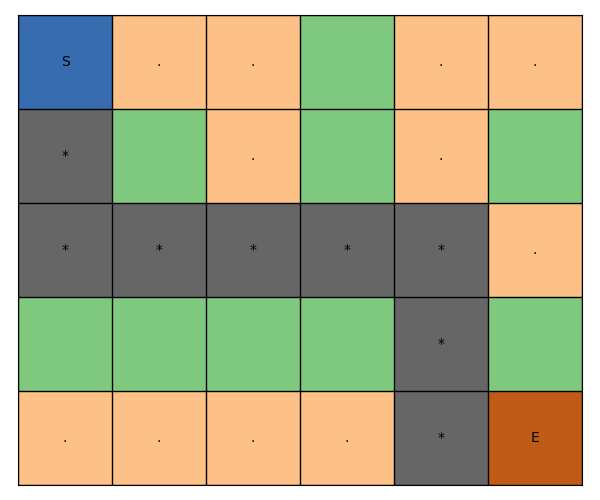

In [14]:
from IPython.display import Image
Image('maze_navigation.png')